# Xenium Prime 5K Breast — V1006 representation-first CCC niches

Only directed CCC enters training. Cell type is used only for interpretation.

In [1]:
from pathlib import Path
import sys, json, numpy as np, pandas as pd, matplotlib.pyplot as plt
ROOT = Path('/home/xueshuailin/CCC_Phe/V1006')
SOURCE = ROOT / 'src'
if str(SOURCE) not in sys.path: sys.path.insert(0, str(SOURCE))
from phenoniche.v1006.pipeline import ensure_results
from phenoniche.v1006.data import load_prepared_input
from phenoniche.v1006.reporting import (training_curves, spatial_overview, niche_celltype_enrichment,
    spatial_each_niche, niche_size_plot, representative_h_heatmap)
artifacts = ensure_results()
summary, output = artifacts['summary'], artifacts['output']


## 1. Prime 5K data summary

In [2]:
pd.Series({'cells': summary['n_cells'], 'original CCC features': summary['n_input_features'],
           'retained CCC features': summary['n_retained_features'], 'latent dimension': 32,
           'final niches': 8}, name='V1006')

cells                    699110
original CCC features       494
retained CCC features       450
latent dimension             32
final niches                  8
Name: V1006, dtype: int64

## 2. Model summary

In [3]:
print('CCC F → 256 → 64 → ReLU Z32 → nonlinear AE decoder')
print('Z32 → fixed train-derived PCA whitening → 8 learnable cosine prototypes → soft assignment Q8')
print('Niche CCC profiles are soft-weighted means of the observed directed CCC vectors.')

CCC F → 256 → 64 → ReLU Z32 → nonlinear AE decoder
Z32 → fixed train-derived PCA whitening → 8 learnable cosine prototypes → soft assignment Q8
Niche CCC profiles are soft-weighted means of the observed directed CCC vectors.


## 3. Training loss

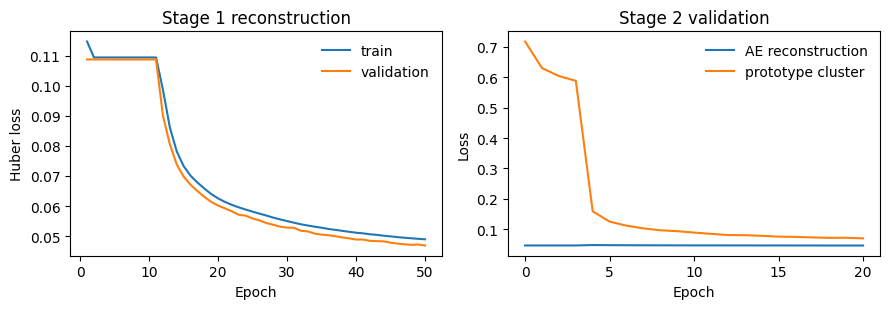

Stage 1 best epoch                   50.000000
Stage 1 validation reconstruction     0.046899
Stage 2 selected epoch               20.000000
Stage 2 validation AE                 0.046724
Stage 2 validation prototype loss     0.070203
dtype: float64

In [4]:
training_curves(output); plt.show()
pd.Series({'Stage 1 best epoch': summary['stage1_best_epoch'],
           'Stage 1 validation reconstruction': summary['stage1_validation_reconstruction'],
           'Stage 2 selected epoch': summary['stage2_best_epoch'],
           'Stage 2 validation AE': summary['stage2_validation_reconstruction'],
           'Stage 2 validation prototype loss': summary['stage2_validation_cluster_loss']})

## 4. Final 8-niche spatial map

V1006 has one CCC-derived final assignment. It therefore shows cell types and V1006 niches, without inventing Composition-only or shared-W panels.

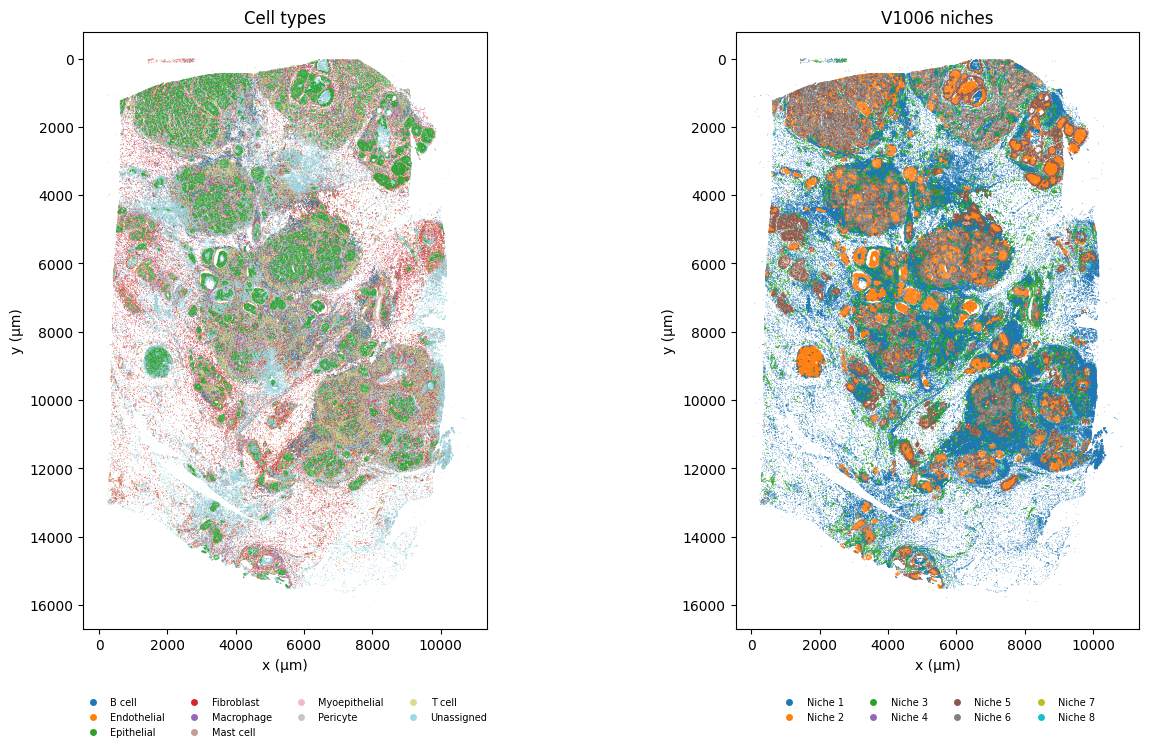

In [5]:
spatial_overview(artifacts); plt.show()

## 5. Niche size and proportion

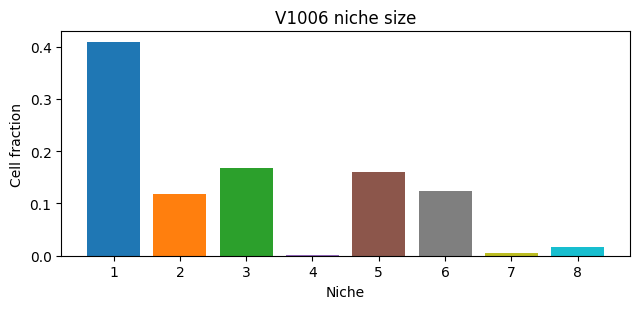

,niche,n_cells,fraction,mean_soft_usage
0,1,285771,0.408764,0.402680
1,2,82580,0.118122,0.113153
2,3,116767,0.167022,0.158754
3,4,334,0.000478,0.017213
4,5,112076,0.160312,0.149716
5,6,86547,0.123796,0.117219
6,7,3138,0.004489,0.018029
7,8,11897,0.017017,0.020784


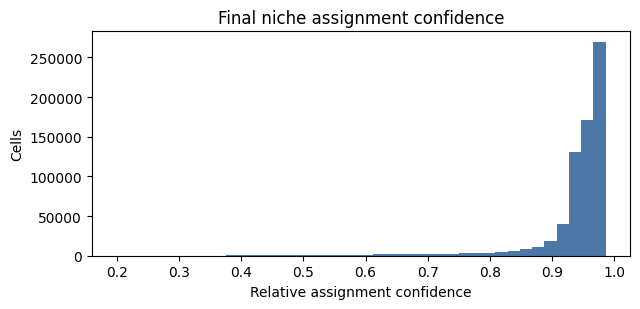

,confidence
count,699110.000000
mean,0.938186
std,0.082067
min,0.198744
10%,0.889501
25%,0.937169
50%,0.954453
75%,0.985130
90%,0.985256
max,0.986289


In [6]:
niche_size_plot(artifacts); plt.show()
display(artifacts['counts'])
confidence = artifacts['assignments']['assignment_confidence_relative']
fig, ax = plt.subplots(figsize=(6.5, 3.2)); ax.hist(confidence, bins=40, color='#4c78a8')
ax.set(xlabel='Relative assignment confidence', ylabel='Cells', title='Final niche assignment confidence')
plt.tight_layout(); plt.show()
pd.Series(confidence).describe(percentiles=[.1,.25,.5,.75,.9]).to_frame('confidence')

## 6. Cell-type / niche summary

Cell type is used here only after training.

/home/xueshuailin/miniconda3/envs/cccphe/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


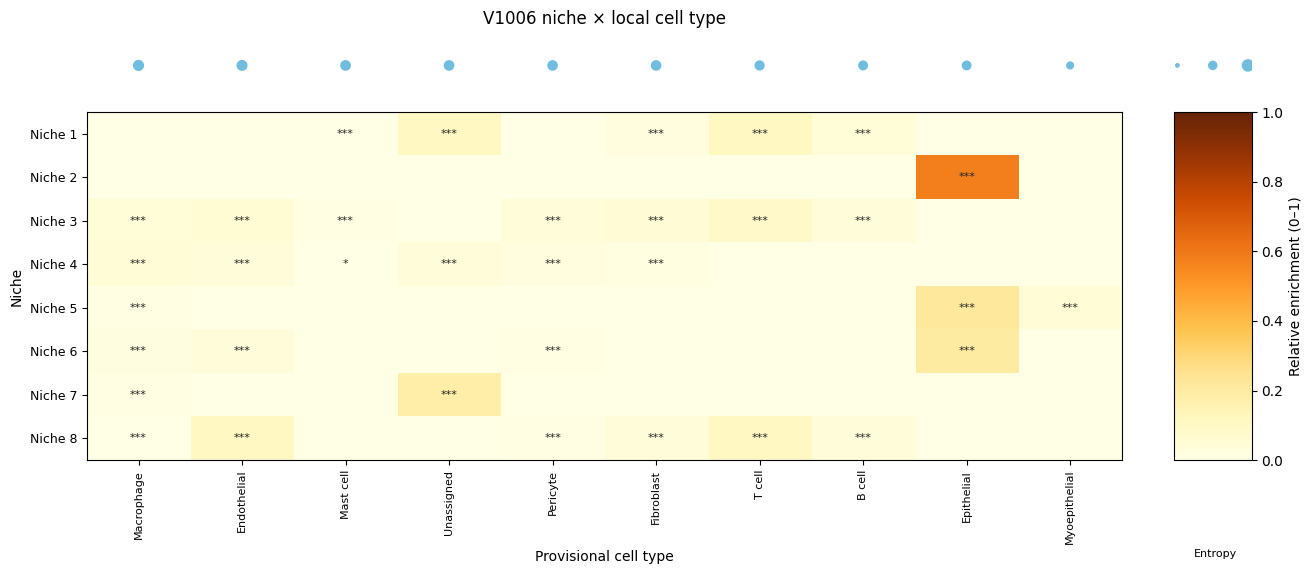

Stars: one-sided Mann–Whitney U, * p≤0.05, ** p≤0.001, *** p≤0.0001; dot size: across-niche entropy.


In [7]:
_, enrichment_table = niche_celltype_enrichment(artifacts); plt.show()
print('Stars: one-sided Mann–Whitney U, * p≤0.05, ** p≤0.001, *** p≤0.0001; dot size: across-niche entropy.')

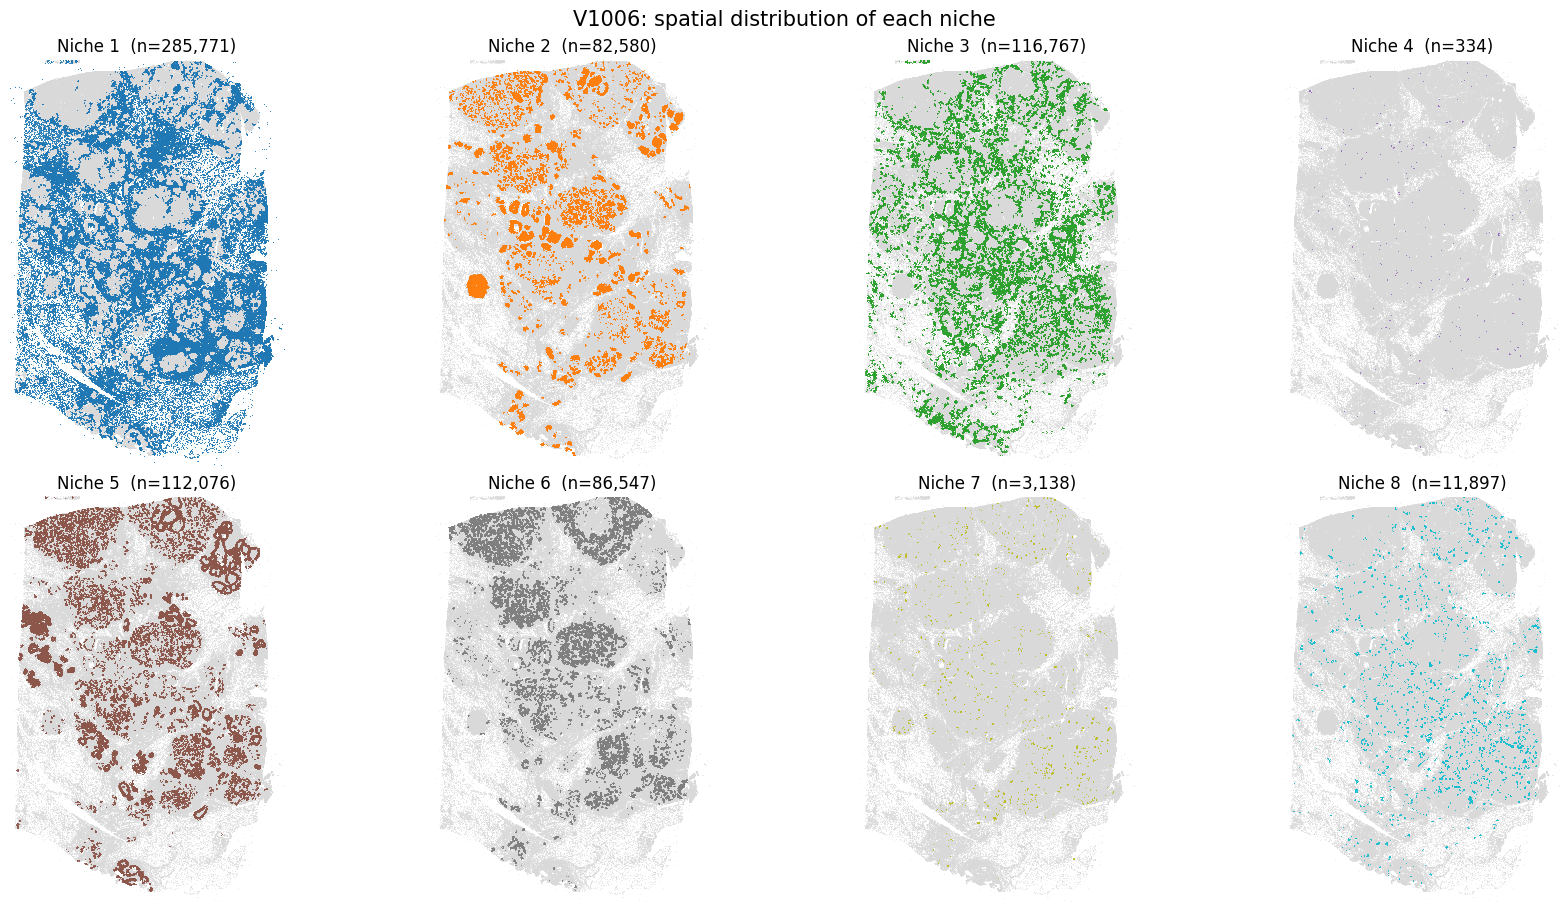

In [8]:
spatial_each_niche(artifacts); plt.show()

## 7. Representative CCC

In [9]:
for niche in range(1, 9):
    print(f'\nNiche {niche}')
    display(artifacts['top_ccc'].query('niche == @niche')[['rank','ccc','weight']].head(15).reset_index(drop=True))
print('Top sender → receiver')
display(pd.read_csv(output/'top_sender_receiver.csv').groupby('niche', group_keys=False).head(5))
print('Top ligand–receptor')
display(pd.read_csv(output/'top_lr.csv').groupby('niche', group_keys=False).head(5))


Niche 1


,rank,ccc,weight
0,1,Fibroblast → Macrophage | CCL2–CCR1,0.061209
1,2,Macrophage → Macrophage | CCL2–CCR1,0.017047
2,3,Fibroblast → T cell | TIMP2–CD44,0.015439
3,4,Fibroblast → Macrophage | THY1–ITGAX,0.047684
4,5,Macrophage → T cell | PKM–CD44,0.018132
5,6,Fibroblast → T cell | VEGFA–CD44,0.015811
6,7,Mast cell → Fibroblast | LIF–IL6ST,0.008986
7,8,Fibroblast → Macrophage | THY1–ITGB2,0.030465
8,9,Macrophage → Fibroblast | ITGB2–THY1,0.030465
9,10,Fibroblast → T cell | TIMP3–CD44,0.071339



Niche 2


,rank,ccc,weight
0,1,Epithelial → Epithelial | GJA1–GJA1,0.011947
1,2,Epithelial → Epithelial | VEGFB–RET,0.013036
2,3,Epithelial → Epithelial | ALCAM–ALCAM,0.029549
3,4,Epithelial → Epithelial | VEGFA–RET,0.008696
4,5,Epithelial → Epithelial | CALM3–ESR1,0.022641
5,6,Epithelial → Epithelial | TIMP3–DDR1,0.136559
6,7,Epithelial → Epithelial | GNAI2–ADORA1,0.012384
7,8,Epithelial → Epithelial | MPZL1–MPZL1,0.005706
8,9,Epithelial → Epithelial | CD44–CLDN7,0.012656
9,10,Epithelial → Epithelial | TIMP2–CD44,0.012658



Niche 3


...

,rank,ccc,weight
0,1,Endothelial → Endothelial | PECAM1–PECAM1,0.073478
1,2,Endothelial → Endothelial | PECAM1–ITGB3,0.014599
2,3,Endothelial → Endothelial | COL4A2–CD93,0.040645
3,4,Endothelial → Endothelial | PTPRM–PTPRM,0.006675
4,5,Endothelial → Endothelial | COL4A1–CD93,0.053425
5,6,Endothelial → Endothelial | APP–FLT1,0.054276
6,7,Endothelial → Endothelial | ENG–BMPR2,0.010518
7,8,Endothelial → Endothelial | THY1–ITGB3,0.004531
8,9,Endothelial → Endothelial | COL4A2–ITGB3,0.006698
9,10,Endothelial → Endothelial | TIMP3–ADAMTS4,0.005753


Top sender → receiver


,niche,rank,sender,receiver,weight,sender_receiver
0,1,1,Fibroblast,Macrophage,0.409918,Fibroblast → Macrophage
1,1,2,Fibroblast,T cell,0.118776,Fibroblast → T cell
2,1,3,Fibroblast,Endothelial,0.075301,Fibroblast → Endothelial
3,1,4,Macrophage,Macrophage,0.073410,Macrophage → Macrophage
4,1,5,Epithelial,Epithelial,0.033452,Epithelial → Epithelial
15,2,1,Epithelial,Epithelial,0.785454,Epithelial → Epithelial
16,2,2,Epithelial,Macrophage,0.075539,Epithelial → Macrophage
17,2,3,Macrophage,Epithelial,0.040135,Macrophage → Epithelial
18,2,4,Epithelial,T cell,0.025818,Epithelial → T cell
19,2,5,Fibroblast,Epithelial,0.012173,Fibroblast → Epithelial


Top ligand–receptor


,niche,rank,ligand,receptor,weight,lr
0,1,1,TIMP3,CD44,0.184493,TIMP3–CD44
1,1,2,SERPINE1,PLAUR,0.085771,SERPINE1–PLAUR
2,1,3,CCL2,CCR1,0.083586,CCL2–CCR1
3,1,4,COL4A1,CD44,0.058310,COL4A1–CD44
4,1,5,THY1,ITGAX,0.050275,THY1–ITGAX
15,2,1,TIMP3,DDR1,0.140116,TIMP3–DDR1
16,2,2,TIMP3,CD44,0.130525,TIMP3–CD44
17,2,3,F11R,F11R,0.059315,F11R–F11R
18,2,4,PKM,CD44,0.056882,PKM–CD44
19,2,5,THBS1,SDC4,0.036591,THBS1–SDC4


## 8. Empirical niche CCC-profile heatmap

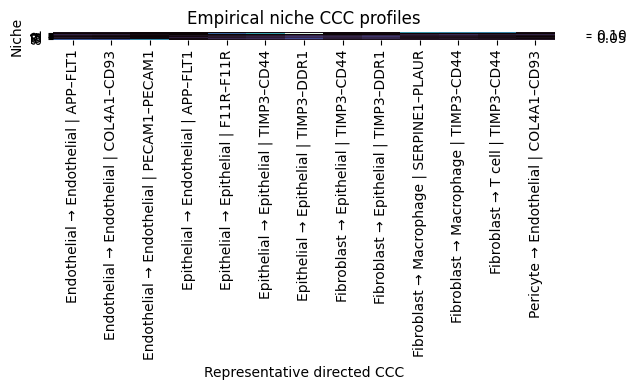

In [10]:
prepared = load_prepared_input(artifacts['config'])
representative_h_heatmap(artifacts['H8'], prepared.features); plt.show()

## 9. Prototype diagnostics

,niche,n_cells,fraction,mean_soft_usage
0,1,285771,0.408764,0.402680
1,2,82580,0.118122,0.113153
2,3,116767,0.167022,0.158754
3,4,334,0.000478,0.017213
4,5,112076,0.160312,0.149716
5,6,86547,0.123796,0.117219
6,7,3138,0.004489,0.018029
7,8,11897,0.017017,0.020784


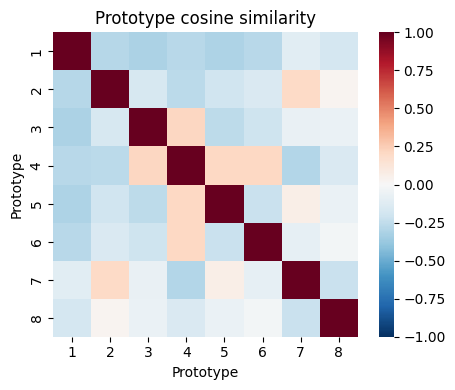

In [11]:
display(artifacts['counts'])
prototype_similarity = pd.read_csv(output/'prototype_cosine_similarity.csv', index_col=0)
fig, ax = plt.subplots(figsize=(5,4));
import seaborn as sns
sns.heatmap(prototype_similarity, vmin=-1, vmax=1, center=0, cmap='RdBu_r', square=True, ax=ax)
ax.set(title='Prototype cosine similarity', xlabel='Prototype', ylabel='Prototype'); plt.tight_layout(); plt.show()

## 10. Final summary

In [12]:
top = artifacts['top_ccc'].query('rank == 1').set_index('niche')['ccc'].to_dict()
print(f"All 8 niches used: {not summary['niche_collapse']}")
print(f"Severe niche imbalance: {summary['severe_imbalance']}")
print(f"Largest niche fraction: {max(summary['niche_cell_fractions']):.3%}")
print(f"Mean assignment confidence: {summary['mean_assignment_confidence']:.3f}")
print(f"Maximum off-diagonal prototype cosine: {summary['prototype_max_offdiagonal_cosine']:.3f}")
display(pd.Series(top, name='Top representative CCC').rename_axis('Niche').to_frame())

All 8 niches used: True
Severe niche imbalance: True
Largest niche fraction: 40.876%
Mean assignment confidence: 0.938
Maximum off-diagonal prototype cosine: 0.213


,Top representative CCC
Niche,
1,Fibroblast → Macrophage | CCL2–CCR1
2,Epithelial → Epithelial | GJA1–GJA1
3,Pericyte → Fibroblast | IL6–IL6ST
4,Epithelial → Pericyte | TIMP3–ADAMTS4
5,Myoepithelial → Myoepithelial | TIMP3–DDR1
6,Endothelial → Epithelial | COL4A1–ITGA2
7,Epithelial → Mast cell | KITLG–KIT
8,Endothelial → Endothelial | PECAM1–PECAM1
